In [1]:
import sklearn
import numpy as np

# to make this notebook's output stable across runs
np.random.seed(342)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Linear Regression


### The Normal Equation


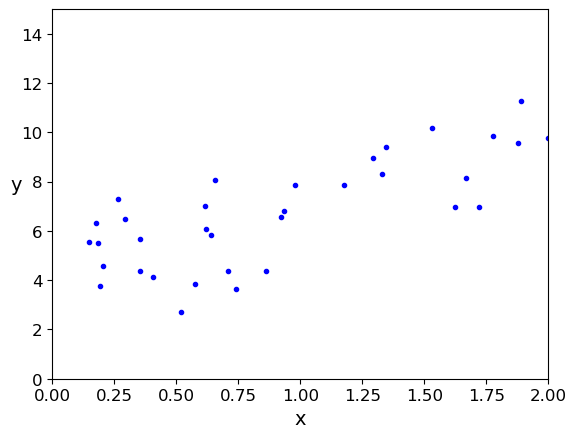

In [2]:
# to get a linear distribution

X = 2 * np.random.randn(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

plt.plot(X, y, "b.")
plt.xlabel("x")
plt.ylabel("y", rotation=0)
plt.axis([0, 2, 0, 15])
plt.show()

_Normal Equation_

$$
\hat{\theta} = (X^T X)^{-1} X^T y
$$


In [3]:
X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

theta_best

array([[4.07183375],
       [3.00741874]])

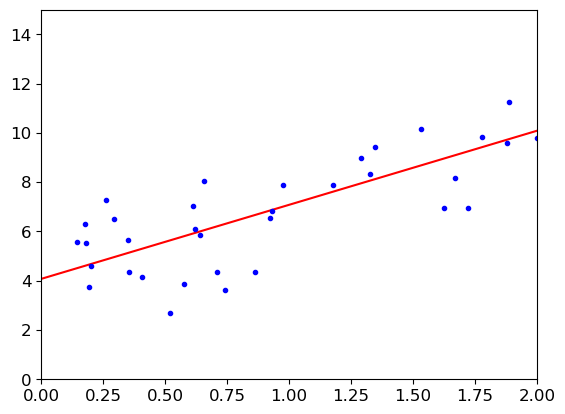

In [4]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]  # add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

### Using sklearn


In [5]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.07183375]), array([[3.00741874]]))

In [6]:
lin_reg.predict(X_new)

array([[ 4.07183375],
       [10.08667124]])

# Polynomial Regression


In [7]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

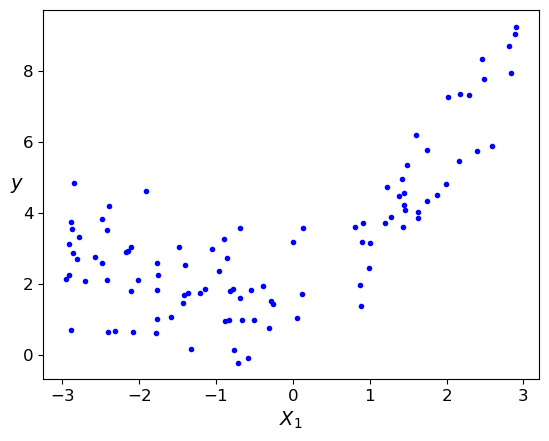

In [8]:
plt.plot(X, y, "b.")
plt.xlabel("$X_1$")
plt.ylabel("$y$", rotation=0)
plt.show()

In [9]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X_poly

array([[ 1.38616923e+00,  1.92146512e+00],
       [-1.75087600e+00,  3.06556678e+00],
       [-1.77055017e+00,  3.13484791e+00],
       [ 1.87020063e+00,  3.49765040e+00],
       [ 1.60580672e+00,  2.57861522e+00],
       [-2.01245419e+00,  4.04997189e+00],
       [-2.86692531e+00,  8.21926070e+00],
       [-2.31051892e+00,  5.33849769e+00],
       [ 1.43995857e+00,  2.07348068e+00],
       [ 1.99313078e+00,  3.97257030e+00],
       [ 1.19833474e+00,  1.43600616e+00],
       [-2.90662228e+00,  8.44845308e+00],
       [-8.28790170e-01,  6.86893145e-01],
       [-2.70585165e+00,  7.32163316e+00],
       [ 1.63231253e+00,  2.66444420e+00],
       [-2.87694177e+00,  8.27679396e+00],
       [ 1.44797280e+00,  2.09662522e+00],
       [-2.42185256e+00,  5.86536982e+00],
       [ 9.16106032e-01,  8.39250261e-01],
       [-2.84345431e+00,  8.08523239e+00],
       [ 2.48249351e+00,  6.16277403e+00],
       [-1.14866065e+00,  1.31942130e+00],
       [-2.41722444e+00,  5.84297399e+00],
       [-2.

In [10]:
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([2.02424646]), array([[0.93557692, 0.46126514]]))

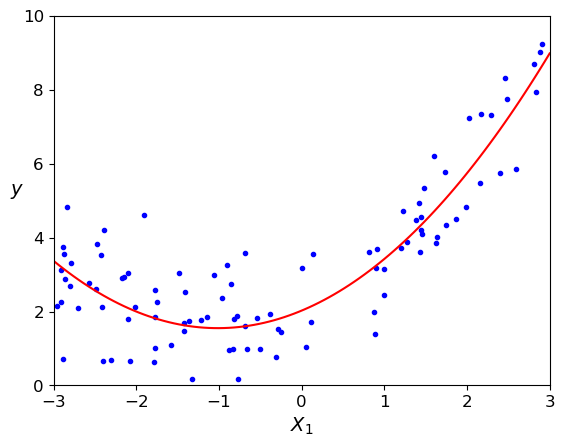

In [11]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-")
plt.xlabel("$X_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.show()

In [12]:
%whos

Variable             Type                  Data/Info
----------------------------------------------------
LinearRegression     ABCMeta               <class 'sklearn.linear_mo<...>._base.LinearRegression'>
PolynomialFeatures   type                  <class 'sklearn.preproces<...>mial.PolynomialFeatures'>
X                    ndarray               100x1: 100 elems, type `float64`, 800 bytes
X_b                  ndarray               100x2: 200 elems, type `float64`, 1600 bytes
X_new                ndarray               100x1: 100 elems, type `float64`, 800 bytes
X_new_b              ndarray               2x2: 4 elems, type `float64`, 32 bytes
X_new_poly           ndarray               100x2: 200 elems, type `float64`, 1600 bytes
X_poly               ndarray               100x2: 200 elems, type `float64`, 1600 bytes
lin_reg              LinearRegression      LinearRegression()
mpl                  module                <module 'matplotlib' from<...>matplotlib\\__init__.py'>
np             

## Learning Curves


**Learning curves** are plots of training and validation error versus training set size.

**Why needed:**
They help diagnose model behavior:

- High training & validation error → underfitting
- Low training but high validation error → overfitting
- Both low and close → good generalization

**Benefit over cross-validation:**
Cross-validation gives a performance estimate, while learning curves explain _why_ the model behaves that way and indicate whether more data or a different model complexity is needed.


In [13]:


def plot_learning_curves(model, X, y):
    from sklearn.model_selection import learning_curve
    import numpy as np
    import matplotlib.pyplot as plt

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=5,
        shuffle=True,
        random_state=42,
        train_sizes=np.linspace(0.1, 1.0, 30),
        n_jobs=-1,
    )

    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)

    plt.plot(train_sizes, train_rmse, "r-+", label="train")
    plt.plot(train_sizes, val_rmse, "b-", label="validation")
    plt.legend()
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")


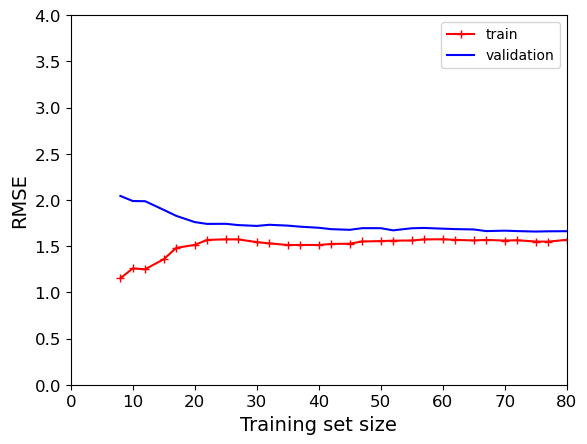

In [14]:
plot_learning_curves(lin_reg, X, y)
plt.axis([0, 80, 0, 4])
plt.show()

**Learning Curve Interpretation (Underfitting / High Bias)**

- With very few training instances, the model fits perfectly → training error ≈ 0.
- As more data is added, perfect fitting becomes impossible due to noise and non-linear patterns → training error increases and reaches a plateau.
- Validation error is initially high because the model cannot generalize from limited data.
- As training data grows, validation error decreases as the model learns better.
- Eventually, both training and validation errors plateau at similar values, indicating the model is too simple (high bias / underfitting).


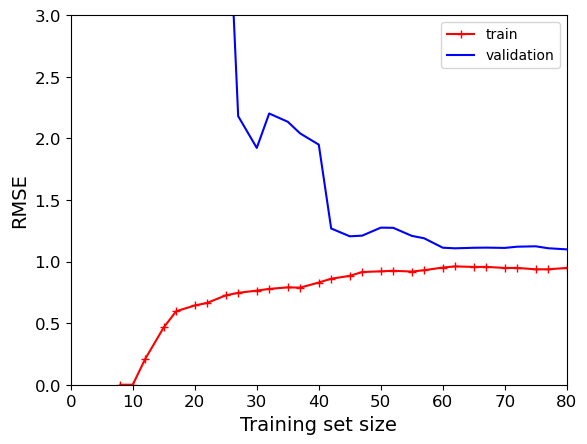

In [15]:
from sklearn.pipeline import Pipeline

polynomial_regression = Pipeline(
    [
        ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
        ("lin_reg", LinearRegression()),
    ]
)

plot_learning_curves(polynomial_regression, X, y)
plt.axis([0, 80, 0, 3])
plt.show()

# Regularized Linear Models

### Ridge Regression

$$
J(\theta) = \text{MSE}(\theta) + \alpha \frac{1}{2} \sum_{i=1}^{n} \theta_i^2
$$

$$
J(\theta) = \frac{1}{m} \sum_{k=1}^{m} (y^{(k)} - \hat{y}^{(k)})^2
+ \alpha \frac{1}{2} \sum_{i=1}^{n} \theta_i^2
$$

In [16]:
np.random.seed(42)
X = 3 * np.random.rand(20, 1)
y = 1 + 0.5 * X + np.random.randn(20, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)



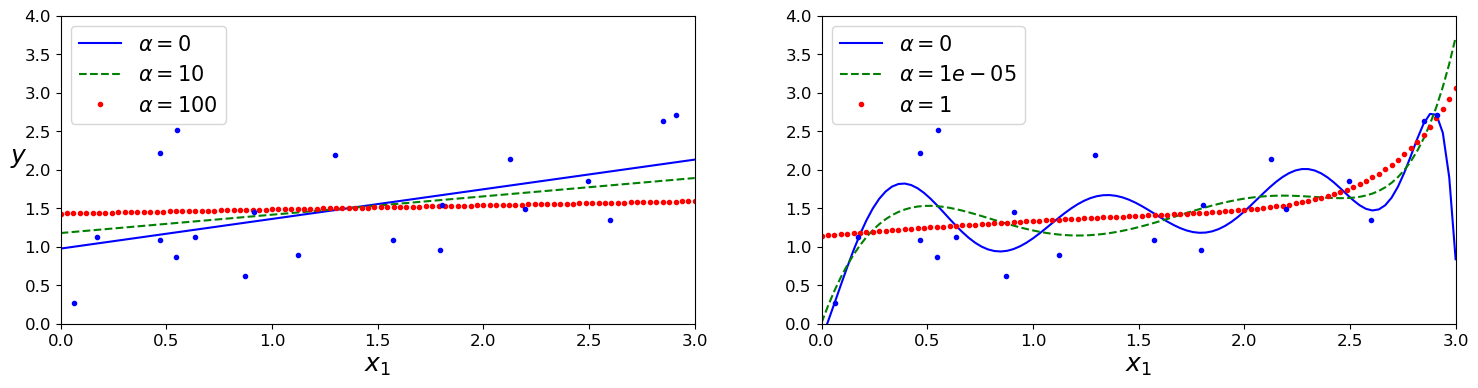

In [17]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

def plot_model(model_class, alphas, polynomial=False, **kwargs):
    for alpha, style in zip(alphas, ("b-", "g--", "r.")):
        model = model_class(alpha, **kwargs) if alpha>0 else LinearRegression()
        if polynomial:
            model = Pipeline([
                ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
                ("scaler", StandardScaler()),
                ("lin_reg", model)
            ])
        model.fit(X, y)
        y_new = model.predict(X_new)
        plt.plot(X_new, y_new, style, label=rf"$\alpha = {alpha}$")

    plt.plot(X, y, "b.", linewidth=3)
    plt.legend(loc="upper left", fontsize=15)
    plt.xlabel("$x_1$", fontsize=18)
    plt.axis([0, 3, 0, 4])

plt.figure(figsize=(18, 4))
plt.subplot(121)
plot_model(Ridge, alphas=(0, 10, 100), polynomial=False, random_state=42)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(122)
plot_model(Ridge, alphas=(0, 10**-5, 1), polynomial=True, random_state=42)
plt.show()

## Lasso Regression

$$
J(\theta) = \text{MSE}(\theta) + \alpha \sum_{i=1}^{n} |\theta_i|
$$

$$
J(\theta) =
\frac{1}{m} \sum_{k=1}^{m} (y^{(k)} - \hat{y}^{(k)})^2
+ \alpha \sum_{i=1}^{n} |\theta_i|
$$

c:\Users\USER\.conda\envs\housing_ml-env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.803e+00, tolerance: 9.295e-04
  model = cd_fast.enet_coordinate_descent(


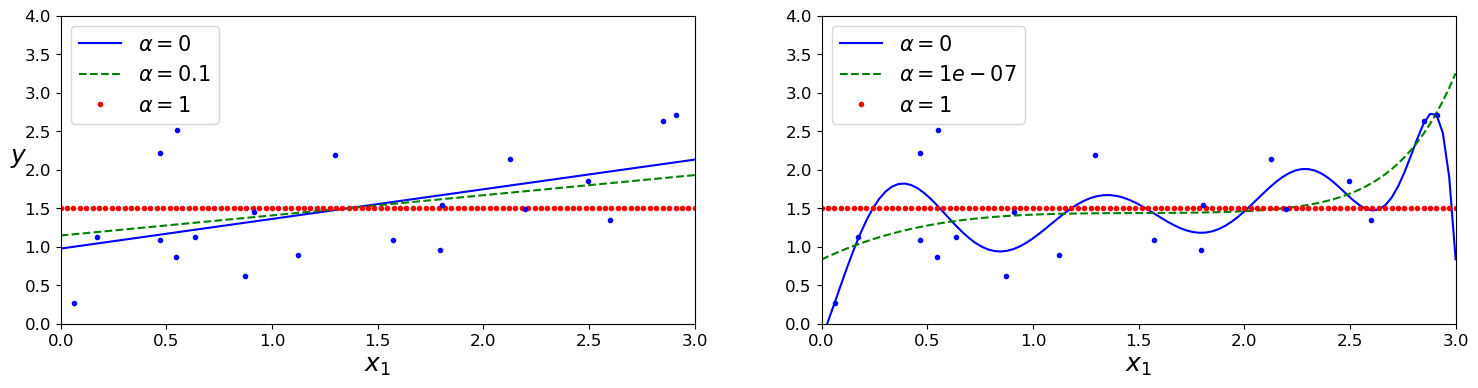

In [19]:
from sklearn.linear_model import Lasso

plt.figure(figsize=(18, 4))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 10**-7, 1), random_state=42)
plt.show()